In [ ]:
!pip install hls4ml qkeras tensorflow
import hls4ml
import qkeras

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation
from qkeras import QDense, QConv2D, QActivation, quantized_bits

# Pobranie danych
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = tf.one_hot(y_train, 10), tf.one_hot(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential([
    Conv2D(8, kernel_size=(3,3), input_shape=(28,28,1), name='conv_0'),
    Activation('relu', name='act_0'),
    MaxPooling2D(pool_size=(2,2), name='pool_0'),
    Flatten(name='flatten'),
    Dense(32, name='dense_0'),
    Activation('relu', name='act_1'),
    Dense(10, name='output_dense'),
    Activation('softmax', name='softmax')
], name='baseline_model')

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train[..., np.newaxis], y_train, epochs=2, batch_size=128)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - accuracy: 0.8763 - loss: 0.4350
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - accuracy: 0.9480 - loss: 0.1780


In [ ]:
import hls4ml
import numpy as np
from sklearn.metrics import accuracy_score

# Definiujemy, które warstwy będziemy kwantyzować
layers_to_test = ['conv_0', 'dense_0', 'output_dense']
results = {}

# Baseline
y_pred_baseline = model.predict(x_test[..., np.newaxis])
acc_baseline = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred_baseline, axis=1))
print(f"Accuracy modelu bazowego (bez kwantyzacji): {acc_baseline:.4f}")

for target_layer in layers_to_test:
    config = hls4ml.utils.config_from_keras_model(model, granularity='name')
    config['Model']['Precision'] = 'ap_fixed<16,6>'

    config['LayerName'][target_layer]['Precision']['weight'] = 'ap_fixed<4,1>'
    config['LayerName'][target_layer]['Precision']['bias'] = 'ap_fixed<4,1>'

    # Symulacja sprzętowa - odajemy parametr part='xc7z020clg484-1', żeby uniknąć błędów z brakiem części
    hls_model = hls4ml.converters.convert_from_keras_model(model, hls_config=config, output_dir='hls_prj', part='xc7z020clg400-1')
    hls_model.compile()

    y_hls = hls_model.predict(x_test[..., np.newaxis])
    acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))
    results[target_layer] = acc
    print(f"Po kwantyzacji {target_layer} na 4-bity, Accuracy wynosi: {acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy modelu bazowego (bez kwantyzacji): 0.9598
Po kwantyzacji conv_0 na 4-bity, Accuracy wynosi: 0.0980
Po kwantyzacji dense_0 na 4-bity, Accuracy wynosi: 0.0980
Po kwantyzacji output_dense na 4-bity, Accuracy wynosi: 0.6732


Zawartość słownika results: {'conv_0': 0.098, 'dense_0': 0.098, 'output_dense': 0.6732}


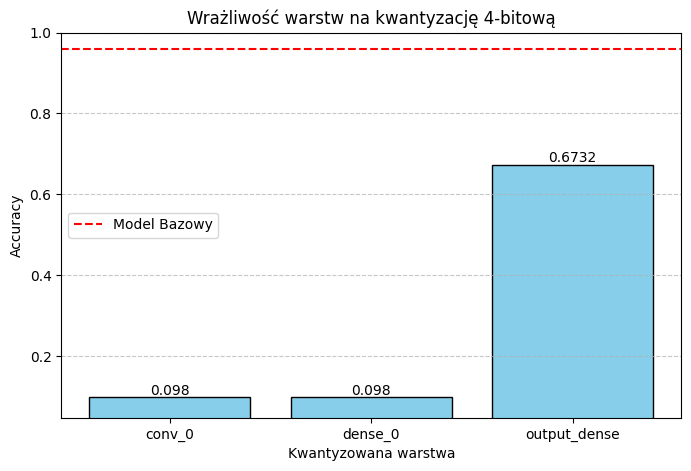

In [ ]:
import matplotlib.pyplot as plt

print("Zawartość słownika results:", results)

if not results:
    print("Błąd: Słownik 'results' jest pusty. Uruchom jeszcze raz pętlę z poprzedniej komórki!")
else:
    names = list(results.keys())
    values = list(results.values())

    plt.figure(figsize=(8, 5))
    bars = plt.bar(names, values, color='skyblue', edgecolor='black')

    plt.ylim(min(values) - 0.05, 1.0)

    plt.title("Wrażliwość warstw na kwantyzację 4-bitową")
    plt.ylabel("Accuracy")
    plt.xlabel("Kwantyzowana warstwa")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(y=acc_baseline, color='r', linestyle='--', label='Model Bazowy')
    plt.legend()

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

    plt.show()